# 1. Importing Required Libraries

### Purpose
-NumPy → numerical operations and 2D arrays (seismic data matrix) <br>
-Matplotlib → visualization of the seismic section <br>
-PIL (Pillow) → drawing text on an image <br>
-SciPy convolve → performing seismic wavelet convolution <br>
#### In geophysics terms, this prepares the tools for creating a reflectivity model and generating synthetic seismic traces. <br>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from scipy.signal import convolve

# 2. Creating the Seismic Canvas

In [5]:
# -----------------------------
# 1. Seismic canvas
# -----------------------------
nt = 1000
nx = 1500

reflectivity = np.random.normal(0,0.02,(nt,nx))

# 3. Creating a Text and Fonts with positioning 

In [7]:
# -----------------------------
# 2. Create text mask
# -----------------------------
img = Image.new("L",(nx,nt),0)
draw = ImageDraw.Draw(img)

# load fonts
try:
    font_big = ImageFont.truetype("C:/Windows/Fonts/arialbd.ttf",140)
    font_small = ImageFont.truetype("C:/Windows/Fonts/arialbd.ttf",50)
except:
    font_big = ImageFont.load_default()
    font_small = ImageFont.load_default()

text1 = "EID"
text2 = "MUBARAK"
signature = "Regards: DR. YASIR"

# --- positions for main words
bbox1 = draw.textbbox((0,0),text1,font=font_big)
bbox2 = draw.textbbox((0,0),text2,font=font_big)

x1 = (nx - bbox1[2])//2
x2 = (nx - bbox2[2])//2

y1 = nt//3
y2 = nt//2

# draw main words
draw.text((x1,y1),text1,fill=255,font=font_big)
draw.text((x2,y2),text2,fill=255,font=font_big)

# --- position for DYB (bottom right)
bbox3 = draw.textbbox((0,0),signature,font=font_small)

x3 = nx - bbox3[2] - 20
y3 = nt - bbox3[3] - 20

draw.text((x3,y3),signature,fill=255,font=font_small)

# Converting Image to Reflectivity
mask = np.array(img)/255


# 4. Assigning Strong Reflectivity and Defining Ricker Wavelet

In [17]:
# -----------------------------
# 1. Assign strong reflectivity
# -----------------------------
reflectivity[mask>0.5] = 1.0

# -----------------------------
# 2. Ricker wavelet
# -----------------------------
def ricker(freq,length,dt):

    t = np.arange(-length/2,length/2,dt)
    w = (1-2*(np.pi*freq*t)**2)*np.exp(-(np.pi*freq*t)**2)

    return w

dt = 0.001
wavelet = ricker(30,0.128,dt)

# 5. Convolution (Seismic Forward Modeling) & Ploting

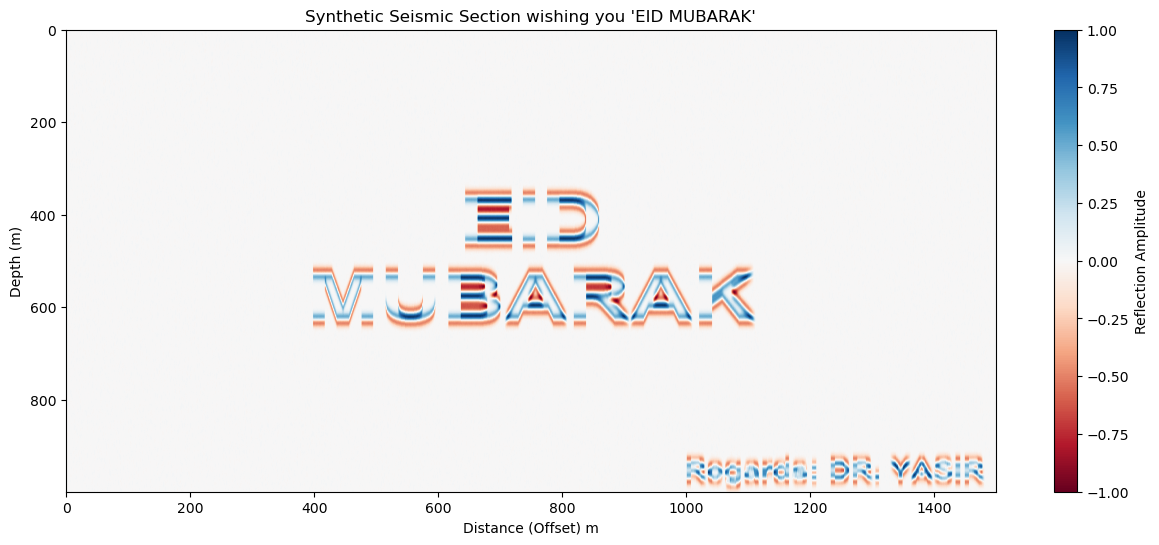

In [26]:
# -----------------------------
# 1. Convolution
# -----------------------------
seismic = np.zeros_like(reflectivity)

for i in range(nx):
    seismic[:,i] = convolve(reflectivity[:,i],wavelet,mode="same")

# -----------------------------
# 2. Add noise
# -----------------------------
noise = np.random.normal(0,0.05,seismic.shape)
seismic += noise

# normalize
seismic = seismic/np.max(np.abs(seismic))

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(15,6))

plt.imshow(seismic,
           cmap="RdBu",
           aspect="auto",
           vmin=-1,
           vmax=1)

plt.title("Synthetic Seismic Section wishing you 'EID MUBARAK'")
plt.xlabel("Distance (Offset) m")
plt.ylabel("Depth (m)")

plt.colorbar(label="Reflection Amplitude")

#to save figure as png
plt.savefig("Eid Mubarak", dpi=600, bbox_inches="tight")

plt.show()

#   Thank you 